In [1]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /home/163f727e-c5be-4e85-a5a2-a0db9cd9644c/KNNeighbours


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Diabetes-Classification.csv')

In [5]:
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [6]:
df.isnull().sum()

Age                           0
Gender                        0
BMI                           3
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    2
Smoking                       2
Diet                          2
Exercise                      1
Diagnosis                     0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.isnull().sum()

Age                           0
Gender                        0
BMI                           0
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    0
Smoking                       0
Diet                          0
Exercise                      0
Diagnosis                     0
dtype: int64

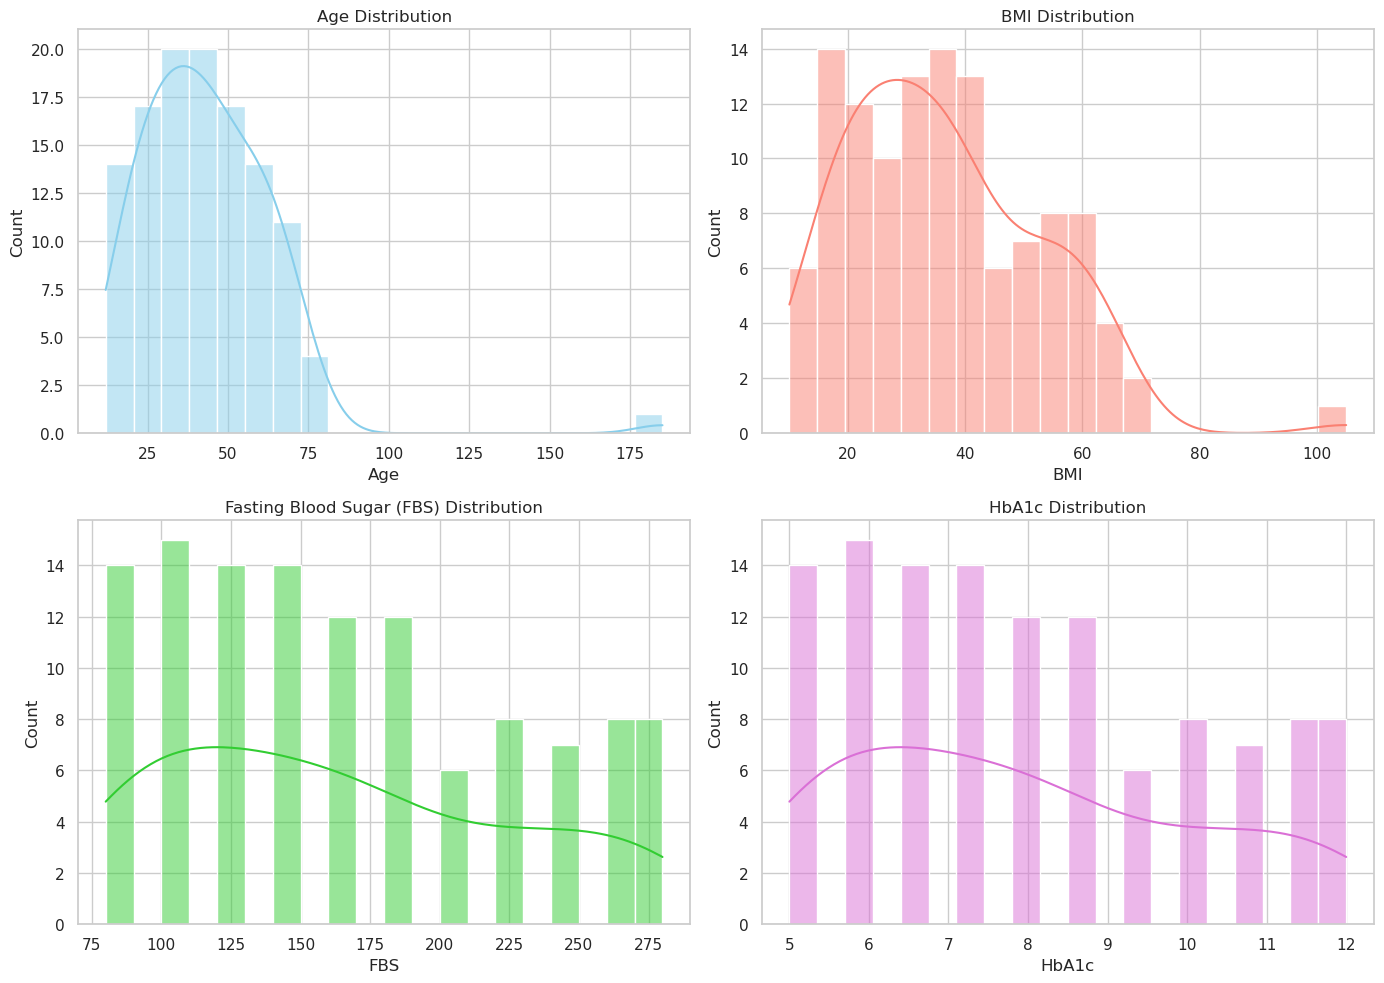

In [9]:
#Descriptive Analysis
sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Age"], bins=20, kde=True, ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title("Age Distribution")

sns.histplot(df["BMI"], bins=20, kde=True, ax=axs[0, 1], color='salmon')
axs[0, 1].set_title("BMI Distribution")

sns.histplot(df["FBS"], bins=20, kde=True, ax=axs[1, 0], color='limegreen')
axs[1, 0].set_title("Fasting Blood Sugar (FBS) Distribution")

sns.histplot(df["HbA1c"], bins=20, kde=True, ax=axs[1, 1], color='orchid')
axs[1, 1].set_title("HbA1c Distribution")

plt.tight_layout()
plt.show()



In [10]:
#Don’t exercise regularly (62.7%)

#Have high blood pressure (61.9%)

#Have no family history of diabetes (60.2%)

#Are smokers (62.7%)

#Have poor diet (62.7%)

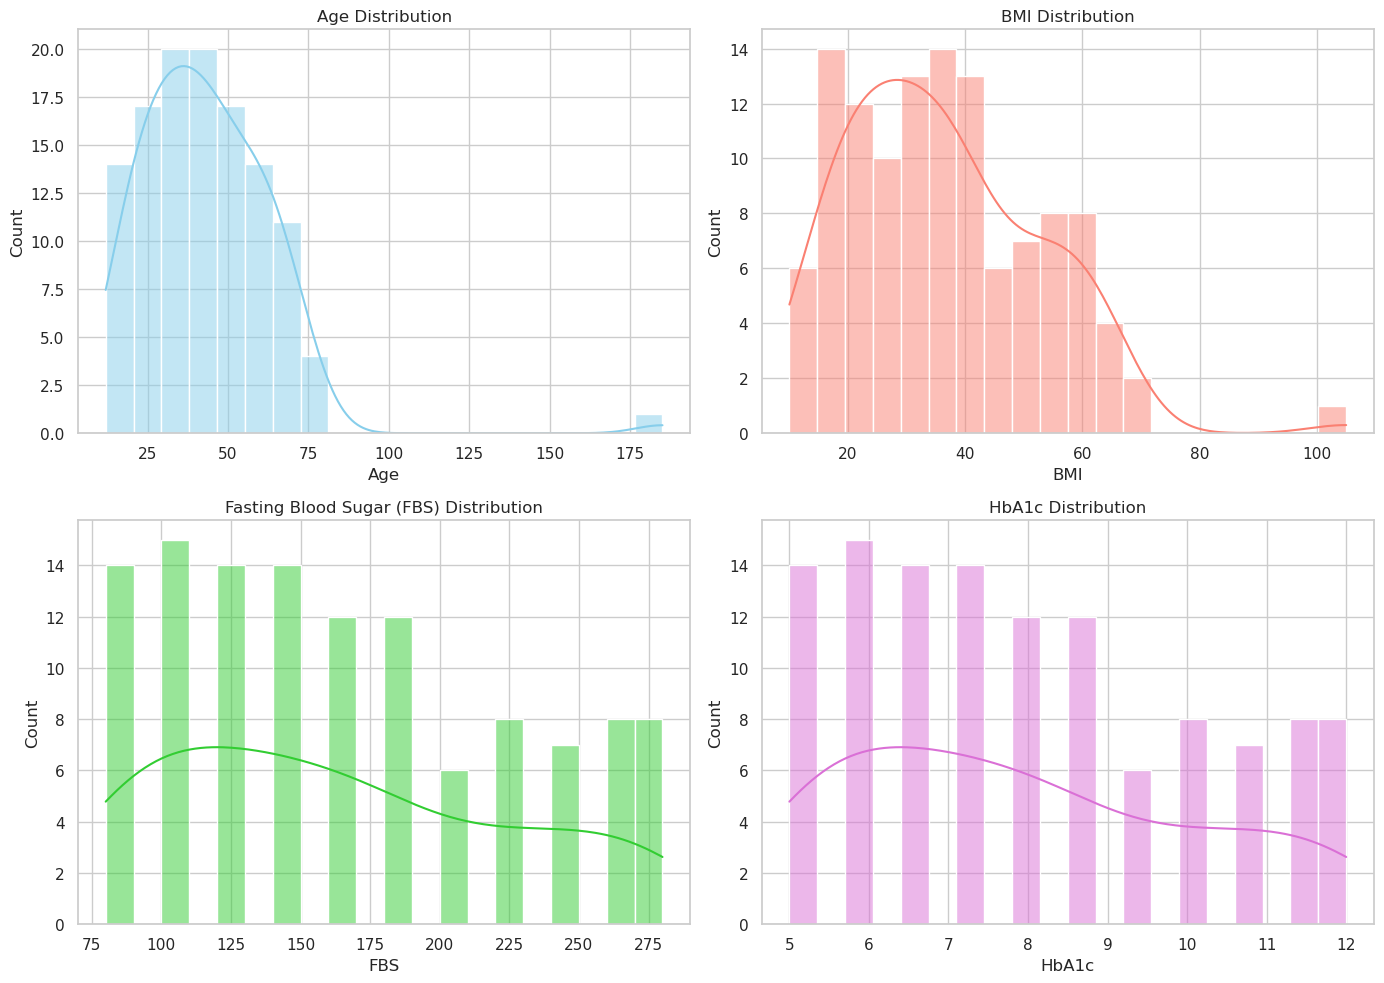

In [11]:
#Distribution Plots for Numerical Features

sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Age"], bins=20, kde=True, ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title("Age Distribution")

sns.histplot(df["BMI"], bins=20, kde=True, ax=axs[0, 1], color='salmon')
axs[0, 1].set_title("BMI Distribution")

sns.histplot(df["FBS"], bins=20, kde=True, ax=axs[1, 0], color='limegreen')
axs[1, 0].set_title("Fasting Blood Sugar (FBS) Distribution")

sns.histplot(df["HbA1c"], bins=20, kde=True, ax=axs[1, 1], color='orchid')
axs[1, 1].set_title("HbA1c Distribution")

plt.tight_layout()
plt.show()


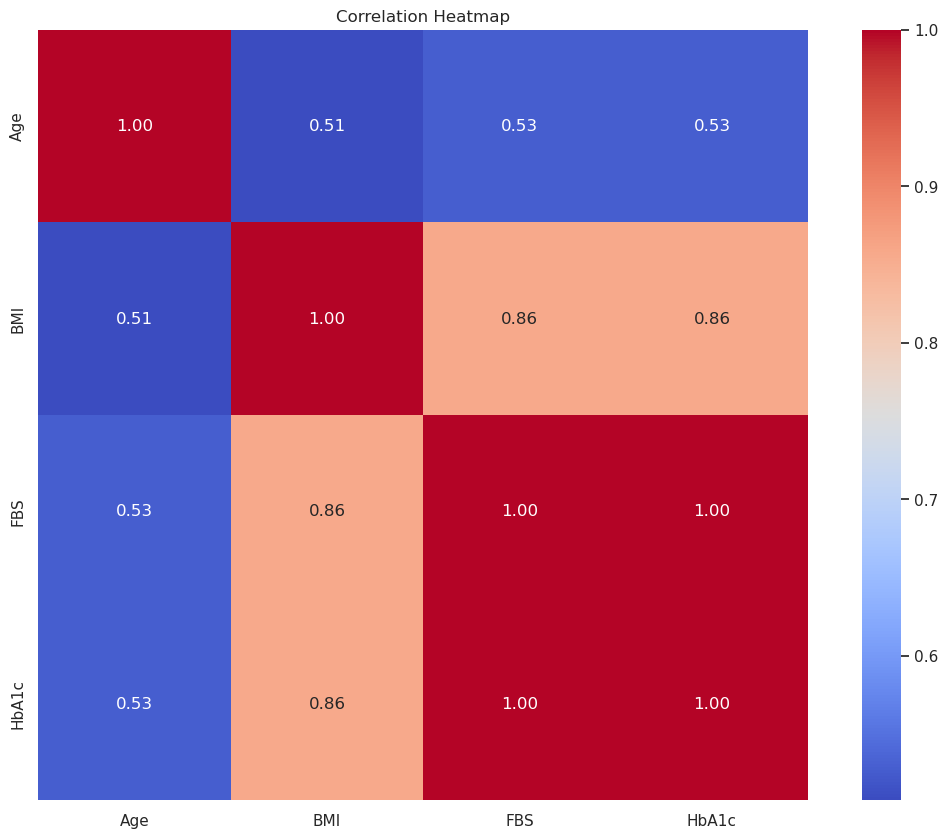

In [12]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()


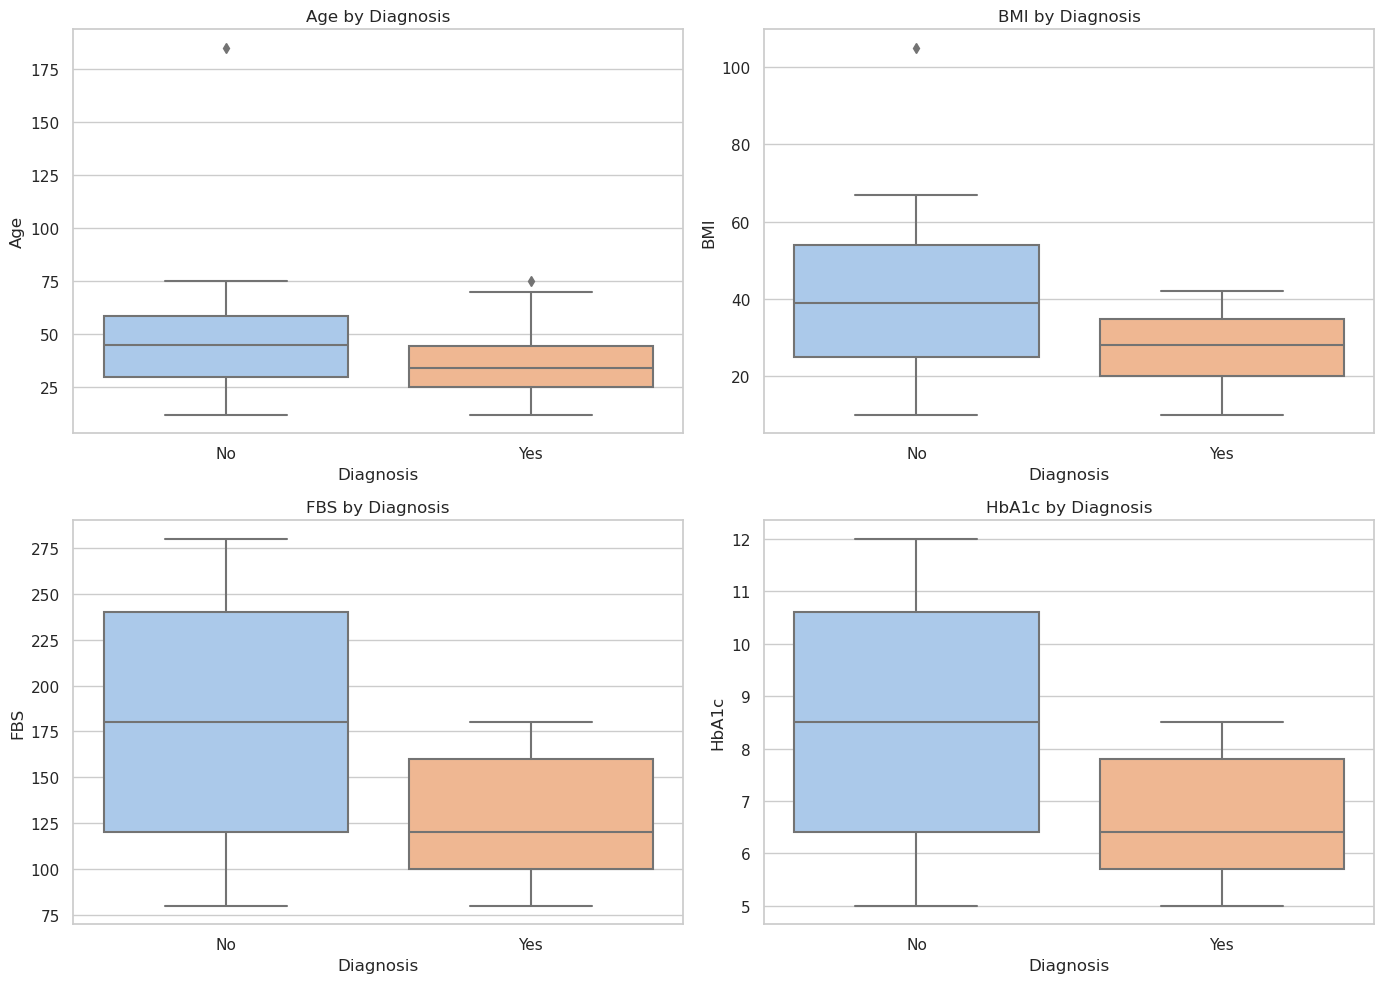

In [13]:
# Ensure Diagnosis is a category
df['Diagnosis'] = df['Diagnosis'].astype('category')

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='Diagnosis', y='Age', data=df, ax=axs[0, 0], palette='pastel')
axs[0, 0].set_title('Age by Diagnosis')

sns.boxplot(x='Diagnosis', y='BMI', data=df, ax=axs[0, 1], palette='pastel')
axs[0, 1].set_title('BMI by Diagnosis')

sns.boxplot(x='Diagnosis', y='FBS', data=df, ax=axs[1, 0], palette='pastel')
axs[1, 0].set_title('FBS by Diagnosis')

sns.boxplot(x='Diagnosis', y='HbA1c', data=df, ax=axs[1, 1], palette='pastel')
axs[1, 1].set_title('HbA1c by Diagnosis')

plt.tight_layout()
plt.show()


In [ ]:
| Feature   | Distribution                                          | Interpretation                                                                        |
| --------- | ----------------------------------------------------- | ------------------------------------------------------------------------------------- |
| **Age**   | Skewed right, with outliers (e.g., 185 years old)     | Data may contain errors. Majority are aged 20–60, relevant for diabetes risk.         |
| **BMI**   | Mostly between 20–60, with extreme outliers up to 105 | High BMI is common, suggesting many are overweight or obese—risk factor for diabetes. |
| **FBS**   | Right-skewed; values often above 120                  | Suggests many individuals have elevated fasting blood sugar, typical in diabetes.     |
| **HbA1c** | Concentrated around 6.5–8.5                           | Suggests that many are in prediabetic or diabetic range (>= 6.5%).                 




Correlation Heatmap
FBS and HbA1c: Very strong correlation (~0.97)
→ Makes sense: both are key diabetes indicators.

BMI and other features: Weak correlation
→ Suggests BMI might add unique value for classification.

Exercise_Regular vs Exercise_No: Perfect inverse (as expected from one-hot encoding).



BOXPLOT DIAGNOSIS

| Feature   | Observation                                                          |
| --------- | -------------------------------------------------------------------- |
| **Age**   | Diabetic individuals tend to be slightly older.                      |
| **BMI**   | Diabetics may have slightly higher BMI, but overlap is large.        |
| **FBS**   | Clear separation: diabetics have significantly higher fasting sugar. |
| **HbA1c** | Also significantly higher among diabetics.                       

✅ Interpretation:
FBS and HbA1c are strong distinguishing features between diabetic and non-diabetic individuals. Age and BMI are moderate predictors.



5. Binary/Categorical Features (Countplots)
Many individuals:

Don't exercise regularly

Have high blood pressure

Are smokers

Have a poor diet

Lack a family history of diabetes (this is notable)

These habits correlate with diabetes risk, though further statistical testing would confirm significance.

SUMMARY Highly informative features: FBS, HbA1c

Moderately useful: Age, BMI, Blood Pressure, Exercise, Diet

Potential issues: Outliers (e.g., age 185), possibly incorrectliers.   |
   |


In [15]:
# Outlier detection

numerical_cols =df.select_dtypes(include=['number']).columns

# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

# Detect and print outliers for each column
for col in numerical_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"\nOutliers in {col}: {len(outliers)}")
    print(outliers[[col]])


# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

#numerical_cols = df.select_dtypes(include=['number']).columns

# Apply outlier removal correctly
df_cleaned_outlier = df.copy()
for col in numerical_cols:
    df_cleaned_outlier = remove_outliers_iqr(df_cleaned_outlier, col)  # Update df_cleaned_outlier


print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_cleaned_outlier.shape)



Outliers in Age: 1
    Age
55  185

Outliers in BMI: 1
       BMI
112  105.0

Outliers in FBS: 0
Empty DataFrame
Columns: [FBS]
Index: []

Outliers in HbA1c: 0
Empty DataFrame
Columns: [HbA1c]
Index: []
Original dataset shape: (118, 11)
Cleaned dataset shape: (116, 11)


In [19]:
cat_col=['Gender','Exercise','Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet']

one_encoded= pd.get_dummies(df_cleaned_outlier,columns=cat_col)

In [20]:
#label encoding the one hot encoded columns to convert all the string values in newly generated columns to integers
cat_col=[ 'Gender_Female',
       'Gender_Male', 'Exercise_No', 'Exercise_Regular', 'Blood Pressure_High',
       'Blood Pressure_Low', 'Blood Pressure_Normal',
       'Family History of Diabetes_No', 'Family History of Diabetes_Yes',
       'Smoking_No', 'Smoking_Yes', 'Diet_Healthy', 'Diet_Poor']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_col:
    one_encoded[col]=le.fit_transform(one_encoded[col])  

In [21]:
one_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_Female,Gender_Male,Exercise_No,Exercise_Regular,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Family History of Diabetes_No,Family History of Diabetes_Yes,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,45,25.0,100,5.7,No,0,1,0,1,0,0,1,1,0,1,0,1,0
1,55,30.0,120,6.4,Yes,1,0,1,0,1,0,0,0,1,0,1,0,1
2,65,35.0,140,7.1,Yes,0,1,1,0,1,0,0,0,1,0,1,0,1
3,75,40.0,160,7.8,Yes,1,0,1,0,1,0,0,0,1,0,1,0,1
5,50,25.0,100,5.7,No,1,0,0,1,0,0,1,1,0,1,0,1,0


In [22]:
#Feature Selection: Removing irrelevant features which does not contribute towards the label(Diagnosis)
#defining feature selection model
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)

In [23]:
#splitting label and features
x=one_encoded.drop('Diagnosis', axis=1)
y=one_encoded['Diagnosis']

In [24]:
x_selected=selector.fit_transform(x,y)
selected_features=x.columns[selector.get_support()]
print(selected_features)

Index(['Exercise_Regular', 'Smoking_No', 'Smoking_Yes', 'Diet_Healthy',
       'Diet_Poor'],
      dtype='object')


In [25]:
x1=one_encoded[selected_features]

In [26]:
#train test split
from sklearn.model_selection import train_test_split

#for all features
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.4,random_state=10)

In [27]:
#for selected features
x1_train, x1_test, y_train, y_test=train_test_split(x,y,test_size=0.4,random_state=10)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)
knn_selected=KNeighborsClassifier(n_neighbors=5)

In [29]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Ensure arrays are C-contiguous
# training models
# all features
x_train_cont = np.ascontiguousarray(x_train)
x_test_cont = np.ascontiguousarray(x_test)
knn = KNeighborsClassifier()  # Initialize if not already done
knn.fit(x_train_cont, y_train)
y_pred_knn = knn.predict(x_test_cont)

# selected features
x1_train_cont = np.ascontiguousarray(x1_train)
x1_test_cont = np.ascontiguousarray(x1_test)
knn_selected = KNeighborsClassifier()  # Initialize if not already done
knn_selected.fit(x1_train_cont, y_train)
y_pred_knn1 = knn_selected.predict(x1_test_cont)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


In [30]:
#classification report

from sklearn.metrics import classification_report

print("nKNN Performance:")
print(classification_report(y_test, y_pred_knn))

print("nKNN_Selected Performance:")
print(classification_report(y_test, y_pred_knn1))

nKNN Performance:
              precision    recall  f1-score   support

          No       0.73      0.75      0.74        36
         Yes       0.10      0.09      0.10        11

    accuracy                           0.60        47
   macro avg       0.41      0.42      0.42        47
weighted avg       0.58      0.60      0.59        47

nKNN_Selected Performance:
              precision    recall  f1-score   support

          No       0.73      0.75      0.74        36
         Yes       0.10      0.09      0.10        11

    accuracy                           0.60        47
   macro avg       0.41      0.42      0.42        47
weighted avg       0.58      0.60      0.59        47



In [31]:
#building svm models
from sklearn.svm import SVC

svm=SVC(kernel='rbf', probability=True,random_state=10 )
svm_selected=SVC(kernel='rbf', probability=True,random_state=10 )

In [32]:
#training models
#all features
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)


#selcted features
svm_selected.fit(x1_train,y_train)
y_pred_svm1=svm_selected.predict(x1_test)

In [33]:
#classification report

from sklearn.metrics import classification_report

print("SVM Performance:")
print(classification_report(y_test, y_pred_svm))

print("nSVM_Selected Performance:")
print(classification_report(y_test, y_pred_svm))

SVM Performance:
              precision    recall  f1-score   support

          No       0.77      1.00      0.87        36
         Yes       0.00      0.00      0.00        11

    accuracy                           0.77        47
   macro avg       0.38      0.50      0.43        47
weighted avg       0.59      0.77      0.66        47

nSVM_Selected Performance:
              precision    recall  f1-score   support

          No       0.77      1.00      0.87        36
         Yes       0.00      0.00      0.00        11

    accuracy                           0.77        47
   macro avg       0.38      0.50      0.43        47
weighted avg       0.59      0.77      0.66        47



/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

<Axes: >

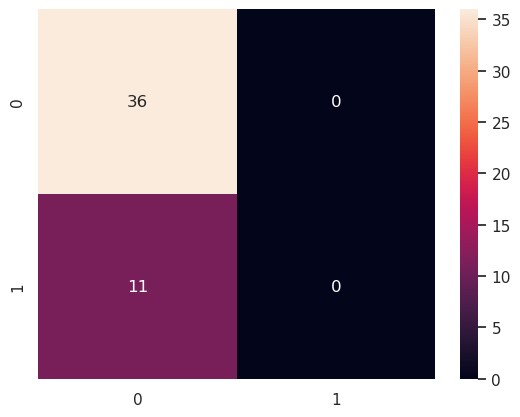

In [34]:
#confusion: it show labelwise performance of the model

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cm,annot=True)

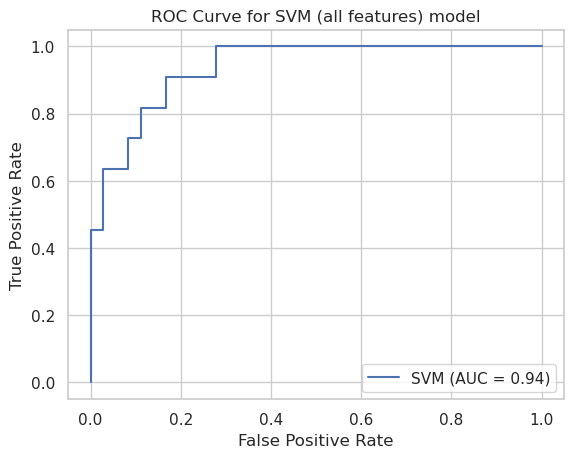

In [63]:
# ROC Curve for all Feature

# Replace 'Yes' with 1 and 'No' with 0
y_test_binary = y_test.replace({'Yes': 1, 'No': 0})

from sklearn.metrics import roc_auc_score, roc_curve

# Get probability of positive class
y_proba = svm.predict_proba(x_test)[:, 1]

# Replace or encode 'Yes'/'No' into binary
y_test_binary = y_test.replace({'Yes': 1, 'No': 0})

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test_binary, y_proba)

# Plot ROC curve
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc_score(y_test_binary, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM (all features) model')
plt.legend()
plt.show()







<Axes: >

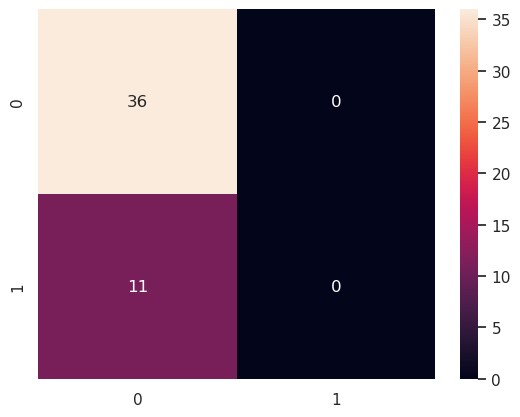

In [61]:
#Selected Feature Confusion matrix 

cm=confusion_matrix(y_test,y_pred_svm1)
sns.heatmap(cm,annot=True)




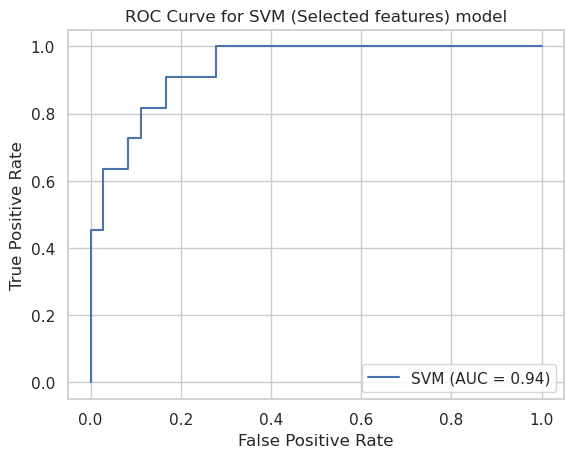

In [65]:
# ROC for selected feature


y_test_binary2 = y_test.replace({'Yes': 1, 'No': 0})

from sklearn.metrics import roc_auc_score, roc_curve

# Get probability of positive class
y_proba2 = svm.predict_proba(x1_test)[:, 1]

# Replace or encode 'Yes'/'No' into binary
y_test_binary2 = y_test.replace({'Yes': 1, 'No': 0})

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test_binary2, y_proba2)

# Plot ROC curve
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc_score(y_test_binary2, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM (Selected features) model')
plt.legend()
plt.show()


##**Analysis with label encoding of features only**
